# Topic Modeling on Reddit Data
Latent Dirichlet Allocation (LDA) to discover the hidden themes in the discussions about Wikipedia and AI. Business Analytics technique to automatically categorize customer feedback and identify key drivers of conversation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## 1. Load the Data
We'll try to load the processed sentiment data, and fall back to the raw scraped data if necessary.

In [3]:
try:
    df = pd.read_csv('../../data/processed/reddit_processed/reddit_combined_sentiment.csv')
    print('Loaded processed sentiment data.')
except FileNotFoundError:
    df = pd.read_csv('../../data/raw/reddit_raw/reddit_ai_wikipedia_posts.csv')
    print('Loaded raw reddit data.')

# combine title and text
df['full_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
print(f'Total posts loaded: {len(df)}')
df.head(5)

Loaded raw reddit data.
Total posts loaded: 684


,subreddit,title,text,score,date,num_comments,url,permalink,id,full_text
0,wikipedia,"Aziz Sergeyevich Shavershian (1989–2011), bett...",NaN,3077,2025-11-12 09:41:04,245,https://en.wikipedia.org/wiki/Zyzz,https://reddit.com/r/wikipedia/comments/1ov0wo...,1ov0wod,"Aziz Sergeyevich Shavershian (1989–2011), bett..."
1,wikipedia,Elizabeth Ann Roberts is an American model who...,NaN,3206,2025-12-09 17:11:44,125,https://en.wikipedia.org/wiki/Elizabeth_Ann_Ro...,https://reddit.com/r/wikipedia/comments/1pid2f...,1pid2fe,Elizabeth Ann Roberts is an American model who...
2,wikipedia,"Later in life, French actress and model Brigit...",NaN,1436,2025-12-30 16:24:44,168,https://en.wikipedia.org/wiki/Brigitte_Bardot#...,https://reddit.com/r/wikipedia/comments/1pzmex...,1pzmex2,"Later in life, French actress and model Brigit..."
3,wikipedia,"Yukio Mishima was a Japanese author, poet, act...",NaN,1269,2025-11-30 20:09:48,48,https://en.wikipedia.org/wiki/Yukio_Mishima,https://reddit.com/r/wikipedia/comments/1pas2n...,1pas2n8,"Yukio Mishima was a Japanese author, poet, act..."
4,wikipedia,Clanker is a slur for robots. The term was ada...,NaN,869,2025-08-12 14:21:30,65,https://en.wikipedia.org/wiki/Clanker,https://reddit.com/r/wikipedia/comments/1moa2c...,1moa2c1,Clanker is a slur for robots. The term was ada...


## 2. Text Preprocessing

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text) # remove URLs
    text = re.sub(r'[^a-z\s]', '', text) # keep only letters
    text = re.sub(r'\s+', ' ', text).strip() # remove extra whitespace
    return text

df['clean_text'] = df['full_text'].apply(clean_text)
df[['full_text', 'clean_text']].head(3)

,full_text,clean_text
0,"Aziz Sergeyevich Shavershian (1989–2011), bett...",aziz sergeyevich shavershian better known as z...
1,Elizabeth Ann Roberts is an American model who...,elizabeth ann roberts is an american model who...
2,"Later in life, French actress and model Brigit...",later in life french actress and model brigitt...


## 3. Vectorization
text documents into a mathematical format (Document-Term Matrix). remove standard English stop words and custom stop words that appear too frequently in our specific context and dilute the topics.

In [5]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# add stop words that don't add unique meaning
custom_stop_words = list(ENGLISH_STOP_WORDS) + ['wikipedia', 'wiki', 'ai', 'chatgpt', 'article', 'articles', 'just', 'like', 'im', 'dont', 'know', 'people', 'think', 'use']

# initialize countVectorizer
# max_df=0.90 means "ignore terms that appear in more than 90% of the documents"
# min_df=5 means "ignore terms that appear in less than 5 documents"
vectorizer = CountVectorizer(max_df=0.90, min_df=5, stop_words=custom_stop_words)

dtm = vectorizer.fit_transform(df['clean_text'])
print(f'Document-Term Matrix shape: {dtm.shape}')

Document-Term Matrix shape: (684, 2186)


## 4. Latent Dirichlet Allocation (LDA)

In [6]:
n_topics = 5
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=15)
lda_model.fit(dtm)
print("LDA Model fitted successfully!")

LDA Model fitted successfully!


## 5. Identifying the Topics
the model output is purely mathematical. look at top words to analyze topics

In [7]:
def display_topics(model, feature_names, no_top_words):
    topic_words = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(f"Topic {topic_idx + 1}:")
        print(" | ".join(top_words))
        print('-'*60)
        topic_words[f"Topic {topic_idx + 1}"] = top_words
    return topic_words

feature_names = vectorizer.get_feature_names_out()
extracted_topics = display_topics(lda_model, feature_names, 12)

Topic 1:
model | user | users | learning | prompt | emergent | responses | models | time | used | ais | context
------------------------------------------------------------
Topic 2:
said | time | mr | way | make | openai | does | chat | research | gpt | did | conversation
------------------------------------------------------------
Topic 3:
model | language | models | data | bert | knowledge | learning | new | text | neural | machine | gpt
------------------------------------------------------------
Topic 4:
gt | rule | game | want | things | ive | make | said | intelligence | help | really | using
------------------------------------------------------------
Topic 5:
human | intelligence | artificial | way | humans | agi | real | trump | world | future | super | time
------------------------------------------------------------


## 6. Assigning Topics & Visualization
Now we assign the most dominant/likely topic to each individual Reddit post and visualize the distribution.

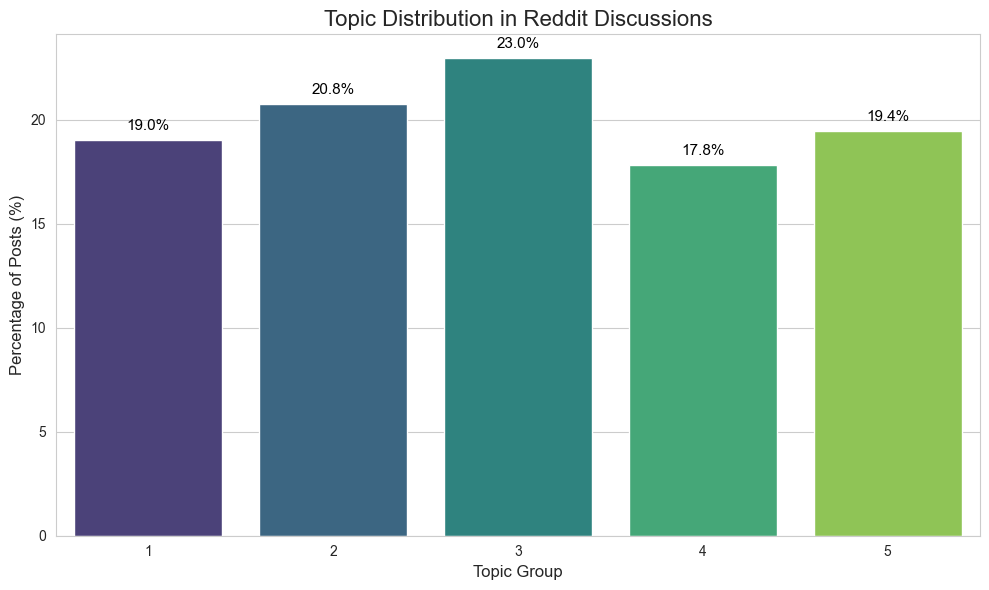

In [8]:
# Get topic probabilities for every document
topic_results = lda_model.transform(dtm)

# argmax gets the index of the highest probability topic (add 1 to match our Topic 1, 2, 3... numbering)
df['dominant_topic'] = topic_results.argmax(axis=1) + 1

# Calculate the percentage each topic makes up
topic_counts = df['dominant_topic'].value_counts().sort_index()
topic_percentages = (topic_counts / topic_counts.sum()) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=topic_percentages.index, y=topic_percentages.values, palette='viridis')
plt.title('Topic Distribution in Reddit Discussions', fontsize=16)
plt.xlabel('Topic Group', fontsize=12)
plt.ylabel('Percentage of Posts (%)', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/topic_distribution.png')
plt.show()

### Examining Specific Rows
Let's look at 3 random posts that were assigned to Topic 1 to verify our qualitative labels make sense:

In [9]:
topic_num = 1
sample_texts = df[df['dominant_topic'] == topic_num]['title'].sample(min(3, len(df[df['dominant_topic'] == topic_num]))).tolist()
for i, text in enumerate(sample_texts):
    print(f"Post {i+1}: {text}")
    print(" ")

Post 1: Just noticed something on Wikipedia I've never seen before: The term "Hallucinated Information."
 
Post 2: The serial killer who promised his victims a modelling career (Wikipedia).
 
Post 3: The Albany Congress: 1754 meeting of representatives sent by of 7 of the colonies in British America: CT, MD, MA, NH, NY, PA, and RI. Though they did not seek to create a nation, this was the first time that American colonists had met, and its model was used in setting up preludes to the Revolution.
 
